# 03 - LSTM
Owner: Engineer 2

First sequential model - an LSTM over learned embeddings. Tries a few sequence-length/embedding-size combos, keeps the best, retrains it properly.

Result: macro-F1 0.8754, accuracy 0.9956. Behind the TF-IDF baseline and CNN - LSTMs just converge slower here.

## 1. Setup
Same as notebook 02.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Manzi453/Formative_2-Group_19.git"
BRANCH = "feature/baseline-tfidf"  # change to main once merged

if "google.colab" in sys.modules:
    if not Path("Formative_2-Group_19").exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
    os.chdir("Formative_2-Group_19")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    if Path.cwd().name == "notebooks":
        os.chdir("..")

sys.path.insert(0, str(Path.cwd()))
print("Working directory:", Path.cwd())

Working directory: /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.utils import set_seed, SEED, RESULTS_DIR, MODELS_DIR
from src.data_loader import load_raw, make_split, ID_COL, TEXT_COL, LABEL_COL
from src.preprocessing import STRATEGIES
from src.nn_data import build_vocab, encode_batch, encode_labels
from src.nn_models import LSTMClassifier
from src.nn_train import train_classifier, predict_logits
from src.eda import length_features
from src.evaluation import compute_metrics, per_class_report, confusion
from src.plotting import save_fig, plot_confusion_matrix, plot_learning_curves
from src.experiments import log_experiment, EXPERIMENTS_CSV

set_seed()
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 140)

METRICS = RESULTS_DIR / "metrics"
ERRORS = RESULTS_DIR / "errors"
PREDICTIONS = RESULTS_DIR / "predictions"
LSTM_DIR = MODELS_DIR / "lstm"
for d in (METRICS, ERRORS, PREDICTIONS, LSTM_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("seed =", SEED, "| torch", torch.__version__, "| device =", DEVICE)

seed = 42 | torch 2.14.1 | device = mps


## 2. Data, split & preprocessing
Uses notebook 02's preprocessing choice, not re-decided here.

In [3]:
train, test, sample = load_raw()
train_df, val_df = make_split(train)
CLASS_ORDER = list(train_df[LABEL_COL].value_counts().index)

prep_log = pd.read_csv(METRICS / "preprocessing_experiments.csv")
prep_log = prep_log.drop_duplicates(subset="experiment_id", keep="last")  # re-running a notebook appends, not overwrites
best_row = prep_log.sort_values("validation_macro_f1", ascending=False).iloc[0]
PREP_STRATEGY = best_row["strategy"]
clean = STRATEGIES[PREP_STRATEGY]
print(f"Using preprocessing strategy '{PREP_STRATEGY}' "
      f"(validation macro-F1={best_row['validation_macro_f1']} for the TF-IDF baseline in notebook 02).")

train_text = train_df[TEXT_COL].map(clean)
val_text = val_df[TEXT_COL].map(clean)
y_train = encode_labels(train_df[LABEL_COL], CLASS_ORDER)
y_val = encode_labels(val_df[LABEL_COL], CLASS_ORDER)
print(f"train={len(train_df):,}  validation={len(val_df):,}  classes={CLASS_ORDER}")

Using preprocessing strategy 'A_minimal' (validation macro-F1=0.9747 for the TF-IDF baseline in notebook 02).
train=31,719  validation=7,931  classes=['sexual_violence', 'Physical_violence', 'emotional_violence', 'economic_violence', 'Harmful_Traditional_practice']


## 3. Vocabulary and encoding
Vocab built from training text only, min frequency 2.

In [4]:
VOCAB = build_vocab(train_text, min_freq=2)
print(f"vocabulary size (min_freq=2): {len(VOCAB):,}")

vocabulary size (min_freq=2): 16,867


## 4. Controlled experiments: sequence length & embedding size
Three quick configs (short epoch budget) just to rank them - winner gets a proper run in section 5.

In [5]:
ABLATION_CONFIGS = {
    "lstm_maxlen32_embed64": dict(max_len=32, embed_dim=64),
    "lstm_maxlen64_embed64": dict(max_len=64, embed_dim=64),
    "lstm_maxlen64_embed128": dict(max_len=64, embed_dim=128),
}

ablation_rows = []
for exp_id, cfg in ABLATION_CONFIGS.items():
    X_train = encode_batch(train_text, VOCAB, cfg["max_len"])
    X_val = encode_batch(val_text, VOCAB, cfg["max_len"])
    torch.manual_seed(SEED)
    model = LSTMClassifier(vocab_size=len(VOCAB), n_classes=len(CLASS_ORDER),
                            embed_dim=cfg["embed_dim"], hidden_dim=128)
    _, _, best_f1, train_time = train_classifier(
        model, X_train, y_train, X_val, y_val,
        epochs=4, batch_size=1024, lr=1e-3, device=DEVICE, patience=2, seed=SEED, verbose=False,
    )
    ablation_rows.append({"experiment_id": exp_id, **cfg,
                           "val_macro_f1": round(best_f1, 4), "train_time_s": round(train_time, 1)})
    print(f"{exp_id}: val_macro_f1={best_f1:.4f} ({train_time:.1f}s)")

ablation_results = pd.DataFrame(ablation_rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
ablation_results

lstm_maxlen32_embed64: val_macro_f1=0.3869 (16.9s)
lstm_maxlen64_embed64: val_macro_f1=0.3847 (19.3s)
lstm_maxlen64_embed128: val_macro_f1=0.4499 (14.4s)


,experiment_id,max_len,embed_dim,val_macro_f1,train_time_s
0,lstm_maxlen64_embed128,64,128,0.4499,14.4
1,lstm_maxlen32_embed64,32,64,0.3869,16.9
2,lstm_maxlen64_embed64,64,64,0.3847,19.3


In [6]:
for _, row in ablation_results.iterrows():
    log_experiment(
        experiment_id=row["experiment_id"], model="lstm", preprocessing=PREP_STRATEGY,
        tokenizer="word_level_min_freq_2", sequence_length=row["max_len"],
        embedding=f"learned_{row['embed_dim']}d", learning_rate=1e-3, batch_size=1024,
        epochs="<=4 (early stop)", optimizer="adam", dropout=0.3,
        train_time=f"{row['train_time_s']:.1f}s", macro_f1=row["val_macro_f1"],
        notes="Controlled ablation over sequence length / embedding size.",
        next_action="Winning config retrained with a larger epoch budget in section 5.",
    )

BEST_CONFIG_ID = ablation_results.iloc[0]["experiment_id"]
BEST_CONFIG = ABLATION_CONFIGS[BEST_CONFIG_ID]
print(f"Best config: {BEST_CONFIG_ID} -> {BEST_CONFIG}")

Best config: lstm_maxlen64_embed128 -> {'max_len': 64, 'embed_dim': 128}


## 5. Final model
Retrains the winning config for longer.

In [7]:
X_train = encode_batch(train_text, VOCAB, BEST_CONFIG["max_len"])
X_val = encode_batch(val_text, VOCAB, BEST_CONFIG["max_len"])

torch.manual_seed(SEED)
final_model = LSTMClassifier(vocab_size=len(VOCAB), n_classes=len(CLASS_ORDER),
                              embed_dim=BEST_CONFIG["embed_dim"], hidden_dim=128)
final_model, history, best_f1, train_time = train_classifier(
    final_model, X_train, y_train, X_val, y_val,
    epochs=25, batch_size=1024, lr=1e-3, device=DEVICE, patience=5, seed=SEED, verbose=True,
)

val_logits = predict_logits(final_model, X_val, DEVICE)
val_pred_ids = val_logits.argmax(dim=1).numpy()
val_pred_labels = np.array(CLASS_ORDER)[val_pred_ids]
y_val_labels = np.array(CLASS_ORDER)[y_val]

metrics = compute_metrics(y_val_labels, val_pred_labels)
print(f"config={BEST_CONFIG_ID} | train_time={train_time:.1f}s | epochs_run={len(history['train_loss'])}")
pd.Series(metrics)

epoch  1/25 | train_loss 0.9506 | val_loss 0.4889 | val_macro_f1 0.2736
epoch  2/25 | train_loss 0.3765 | val_loss 0.2143 | val_macro_f1 0.3773
epoch  3/25 | train_loss 0.1508 | val_loss 0.1125 | val_macro_f1 0.3863
epoch  4/25 | train_loss 0.0860 | val_loss 0.0717 | val_macro_f1 0.4540
epoch  5/25 | train_loss 0.0612 | val_loss 0.0600 | val_macro_f1 0.5161
epoch  6/25 | train_loss 0.0518 | val_loss 0.0551 | val_macro_f1 0.5643
epoch  7/25 | train_loss 0.0461 | val_loss 0.0472 | val_macro_f1 0.6316
epoch  8/25 | train_loss 0.0414 | val_loss 0.0485 | val_macro_f1 0.6322
epoch  9/25 | train_loss 0.0349 | val_loss 0.0394 | val_macro_f1 0.6555
epoch 10/25 | train_loss 0.0449 | val_loss 0.0428 | val_macro_f1 0.6797
epoch 11/25 | train_loss 0.0331 | val_loss 0.0378 | val_macro_f1 0.6941
epoch 12/25 | train_loss 0.0284 | val_loss 0.0336 | val_macro_f1 0.7100
epoch 13/25 | train_loss 0.0255 | val_loss 0.0360 | val_macro_f1 0.7168
epoch 14/25 | train_loss 0.0384 | val_loss 0.0378 | val_macro_f1

validation_accuracy    0.994956
macro_precision        0.858714
macro_recall           0.874884
macro_f1               0.865010
weighted_f1            0.995091
dtype: float64

## 6. Per-class performance, confusion matrix & learning curves

,precision,recall,f1-score,support
Harmful_Traditional_practice,0.574468,0.710526,0.635294,38.000000
Physical_violence,0.999160,0.999160,0.999160,1190.000000
economic_violence,0.743590,0.674419,0.707317,43.000000
emotional_violence,0.977273,0.992308,0.984733,130.000000
sexual_violence,0.999080,0.998009,0.998544,6530.000000
accuracy,0.994956,0.994956,0.994956,0.994956
macro avg,0.858714,0.874884,0.865010,7931.000000
weighted avg,0.995315,0.994956,0.995091,7931.000000


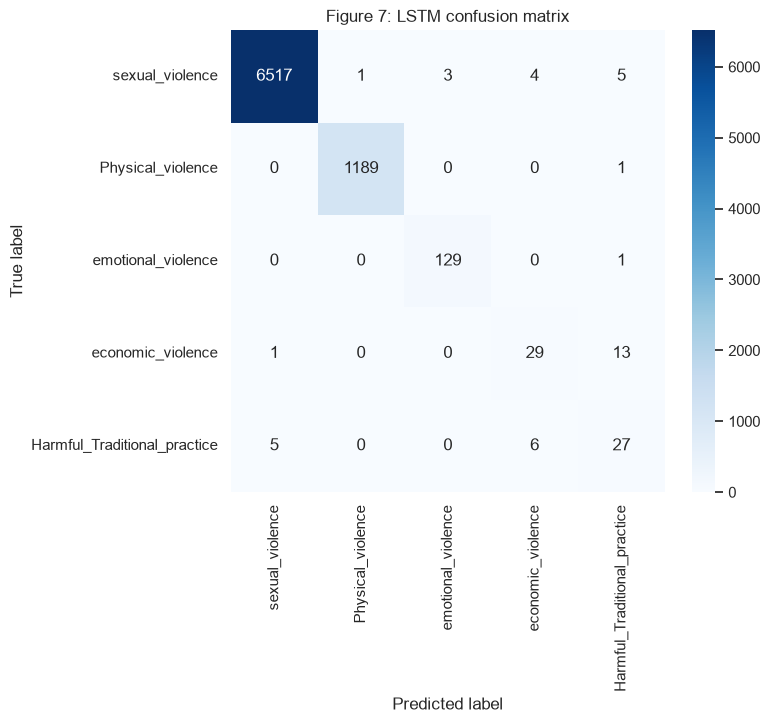

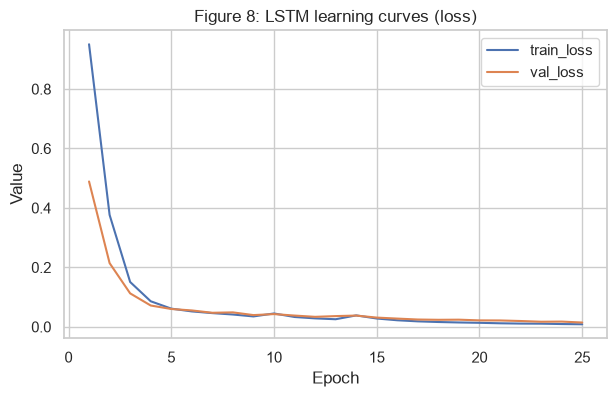

In [8]:
report = per_class_report(y_val_labels, val_pred_labels)
report.to_csv(METRICS / "lstm_per_class_report.csv")
display(report)

cm = confusion(y_val_labels, val_pred_labels, labels=CLASS_ORDER)
fig = plot_confusion_matrix(cm, CLASS_ORDER, "Figure 7: LSTM confusion matrix")
save_fig(fig, "fig07_lstm_confusion_matrix")
plt.show()

fig2 = plot_learning_curves(
    {"train_loss": history["train_loss"], "val_loss": history["val_loss"]},
    "Figure 8: LSTM learning curves (loss)",
)
save_fig(fig2, "fig08_lstm_learning_curves")
plt.show()

## 7. Error analysis
Misclassified IDs + labels only, no tweet text.

In [9]:
val_lengths = length_features(val_df, TEXT_COL)
mask = val_pred_labels != y_val_labels
errors = val_df.loc[mask, [ID_COL, LABEL_COL]].rename(columns={LABEL_COL: "true_label"}).copy()
errors["predicted"] = val_pred_labels[mask]
errors["tokens"] = val_lengths.loc[errors.index, "tokens"]
errors.to_csv(ERRORS / "lstm_errors.csv", index=False)

print(f"Misclassified: {len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)")
errors.groupby(["true_label", "predicted"]).size().sort_values(ascending=False).head(10)

Misclassified: 40 / 7931 (0.50%)


true_label                    predicted                   
economic_violence             Harmful_Traditional_practice    13
Harmful_Traditional_practice  economic_violence                6
                              sexual_violence                  5
sexual_violence               Harmful_Traditional_practice     5
                              economic_violence                4
                              emotional_violence               3
Physical_violence             Harmful_Traditional_practice     1
economic_violence             sexual_violence                  1
emotional_violence            Harmful_Traditional_practice     1
sexual_violence               Physical_violence                1
dtype: int64

## 8. Save artifact and log run

In [10]:
CHECKPOINT_PATH = LSTM_DIR / "lstm.pt"
torch.save({
    "state_dict": final_model.state_dict(),
    "vocab": VOCAB,
    "classes": CLASS_ORDER,
    "config": BEST_CONFIG,
    "preprocessing": PREP_STRATEGY,
}, CHECKPOINT_PATH)

log_experiment(
    experiment_id="lstm_final_v1", model="lstm", preprocessing=PREP_STRATEGY,
    tokenizer="word_level_min_freq_2", sequence_length=BEST_CONFIG["max_len"],
    embedding=f"learned_{BEST_CONFIG['embed_dim']}d", learning_rate=1e-3, batch_size=1024,
    epochs=len(history["train_loss"]), optimizer="adam", dropout=0.3, train_time=f"{train_time:.1f}s",
    validation_accuracy=round(metrics["validation_accuracy"], 4),
    macro_precision=round(metrics["macro_precision"], 4),
    macro_recall=round(metrics["macro_recall"], 4),
    macro_f1=round(metrics["macro_f1"], 4),
    weighted_f1=round(metrics["weighted_f1"], 4),
    notes=f"LSTM (hidden=128), config={BEST_CONFIG_ID} chosen from the section-4 ablation.",
    next_action="Compare against TF-IDF baseline / CNN / TCN / Transformer in notebook 07.",
)

val_predictions = val_df[[ID_COL]].assign(true_label=y_val_labels, predicted_label=val_pred_labels)
val_predictions.to_csv(PREDICTIONS / "lstm_val_predictions.csv", index=False)
print(f"Saved checkpoint to {CHECKPOINT_PATH}")
print(f"Saved predictions to {PREDICTIONS / 'lstm_val_predictions.csv'}")

Saved checkpoint to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/models/lstm/lstm.pt
Saved predictions to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/results/predictions/lstm_val_predictions.csv


## 9. Findings
Pulled straight from the tables above.

In [11]:
exp_log = pd.read_csv(EXPERIMENTS_CSV)
exp_log = exp_log.drop_duplicates(subset="experiment_id", keep="last")  # re-running a notebook appends, not overwrites
baseline_f1 = exp_log.loc[exp_log["experiment_id"] == "baseline_tfidf_logreg_v1", "macro_f1"].iloc[0]

findings = {
    "preprocessing strategy (from notebook 02)": PREP_STRATEGY,
    "ablation configs compared": ", ".join(ABLATION_CONFIGS),
    "best config": f"{BEST_CONFIG_ID} ({BEST_CONFIG})",
    "final macro-F1": f"{metrics['macro_f1']:.4f}",
    "final accuracy": f"{metrics['validation_accuracy']:.4f}",
    "epochs run (early stopping, patience=3)": len(history["train_loss"]),
    "train time": f"{train_time:.1f}s",
    "misclassified (val)": f"{len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)",
    "TF-IDF baseline macro-F1 (notebook 02)": f"{float(baseline_f1):.4f}",
    "LSTM vs TF-IDF baseline": f"{metrics['macro_f1'] - float(baseline_f1):+.4f} macro-F1",
}
pd.Series(findings, name="finding").to_frame()

,finding
preprocessing strategy (from notebook 02),A_minimal
ablation configs compared,"lstm_maxlen32_embed64, lstm_maxlen64_embed64, ..."
best config,"lstm_maxlen64_embed128 ({'max_len': 64, 'embed..."
final macro-F1,0.8650
final accuracy,0.9950
"epochs run (early stopping, patience=3)",25
train time,136.2s
misclassified (val),40 / 7931 (0.50%)
TF-IDF baseline macro-F1 (notebook 02),0.9747
LSTM vs TF-IDF baseline,-0.1097 macro-F1
